# PEMFC Aging Test Load Profiles

This notebook generates common accelerated stress test (AST) load profiles for PEMFC durability testing.

**Profiles included:**
1. **Constant current hold** — steady-state degradation baseline
2. **Square wave cycling** — abrupt load transitions (low ↔ high)
3. **Triangle wave cycling** — gradual ramp load transitions
4. **DOE electrocatalyst AST** — 3s/3s square wave (0.60 V ↔ 0.95 V)
5. **Start-stop cycling** — on/off cycling protocol
6. **NEDC drive cycle** — realistic automotive load from the New European Driving Cycle

All profiles are defined as current density vs. time and are compatible with the `PEMFC_1D` model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# --------------- Set up project root path --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from configuration.initialize import *

print(f"Project root: {project_root}")
print(f"Active area:  {parameters['Aact']*1e4:.0f} cm²")
print(f"Max pola current density: {current_parameters['i_max_pola']:.0f} A/m²  "
      f"({current_parameters['i_max_pola'] * parameters['Aact']:.1f} A)")

Project root: d:\PEMFC\MFC2024
Active area:  30 cm²
Max pola current density: 16500 A/m²  (49.5 A)


## Aging test parameters

Define the common parameters shared across all load profiles.

In [2]:
Aact = parameters["Aact"]  # m². Active area

# Current density levels (A/m²)
i_idle = 0.02e4       # Near-OCV / idle current density
i_low  = 0.20e4       # Low load
i_mid  = 0.50e4       # Medium load (nominal)
i_high = 1.00e4       # High load
i_max  = 1.50e4       # Peak load

# Transition sharpness for smooth tanh ramps (avoids numerical stiffness)
tau_ramp = 2.0  # s — characteristic ramp time

def smooth_step(t, t_switch, tau=tau_ramp):
    """Smooth step from 0 to 1 centered at t_switch."""
    return 0.5 * (1.0 + np.tanh(4.0 * (t - t_switch) / tau))

def smooth_pulse(t, t_on, t_off, tau=tau_ramp):
    """Smooth pulse: rises at t_on, falls at t_off."""
    return smooth_step(t, t_on, tau) - smooth_step(t, t_off, tau)

print("Current density levels (A/m²) → (A):")
for name, val in [("idle", i_idle), ("low", i_low), ("mid", i_mid), ("high", i_high), ("max", i_max)]:
    print(f"  i_{name:>4s} = {val:>8.0f} A/m²  ({val * Aact:>5.1f} A)")

Current density levels (A/m²) → (A):
  i_idle =      200 A/m²  (  0.6 A)
  i_ low =     2000 A/m²  (  6.0 A)
  i_ mid =     5000 A/m²  ( 15.0 A)
  i_high =    10000 A/m²  ( 30.0 A)
  i_ max =    15000 A/m²  ( 45.0 A)


## 1. Constant current hold

Baseline aging profile: the cell operates at a fixed current density for the entire test duration. This isolates steady-state degradation mechanisms (membrane thinning, catalyst dissolution under constant load).

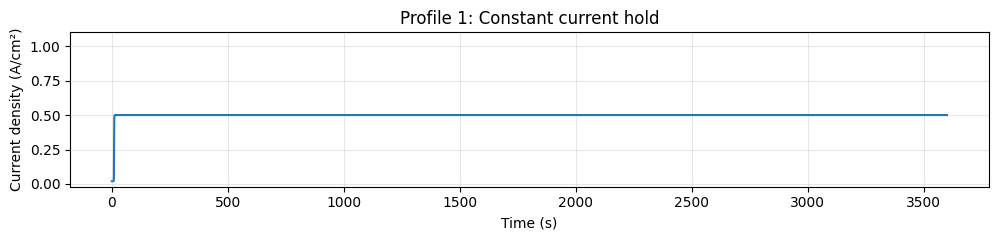

In [3]:
# --- Profile 1: Constant current hold ---
t_hold_total = 3600  # s (1 hour shown)
i_hold = i_mid       # A/m²

def constant_hold_profile(t):
    """Constant current density after a short initial ramp."""
    return i_idle + (i_hold - i_idle) * smooth_step(t, 10.0)

t_hold = np.linspace(0, t_hold_total, 2000)
i_hold_arr = np.array([constant_hold_profile(ti) for ti in t_hold])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_hold, i_hold_arr / 1e4, linewidth=1.5, color="tab:blue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current density (A/cm²)")
ax.set_title("Profile 1: Constant current hold")
ax.set_ylim(-0.02, i_high / 1e4 * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Square wave load cycling

Abrupt transitions between low and high current density. This profile accelerates degradation from repeated load changes — mechanical stress on the membrane and catalyst support corrosion from potential swings.

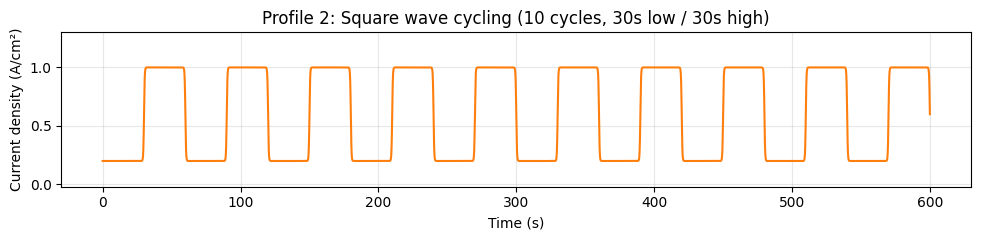

In [4]:
# --- Profile 2: Square wave cycling ---
n_cycles_sq = 10
t_low_sq  = 30   # s at low load
t_high_sq = 30   # s at high load
t_period_sq = t_low_sq + t_high_sq
t_sq_total = n_cycles_sq * t_period_sq

def square_wave_profile(t):
    """Square wave cycling between i_low and i_high."""
    i_fc = i_low
    for k in range(n_cycles_sq):
        t_on  = k * t_period_sq + t_low_sq
        t_off = k * t_period_sq + t_low_sq + t_high_sq
        i_fc = i_fc + (i_high - i_low) * smooth_pulse(t, t_on, t_off)
    return i_fc

t_sq = np.linspace(0, t_sq_total, 5000)
i_sq_arr = np.array([square_wave_profile(ti) for ti in t_sq])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_sq, i_sq_arr / 1e4, linewidth=1.5, color="tab:orange")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current density (A/cm²)")
ax.set_title(f"Profile 2: Square wave cycling ({n_cycles_sq} cycles, "
             f"{t_low_sq}s low / {t_high_sq}s high)")
ax.set_ylim(-0.02, i_high / 1e4 * 1.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Triangle wave load cycling

Gradual ramp up / ramp down between low and high load. Compared to the square wave, this produces smoother water management transients and more uniform mechanical fatigue.

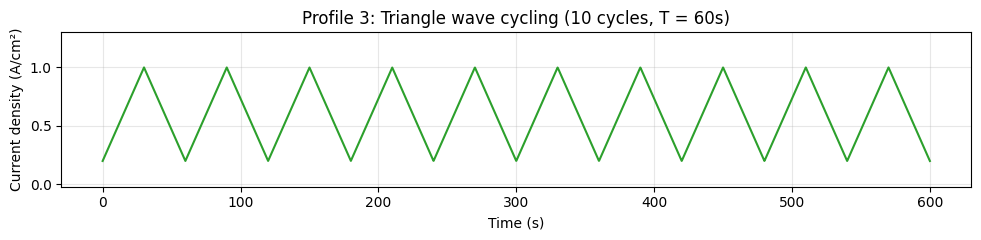

In [5]:
# --- Profile 3: Triangle wave cycling ---
n_cycles_tri = 10
t_period_tri = 60  # s per full cycle
t_tri_total = n_cycles_tri * t_period_tri

def triangle_wave_profile(t):
    """Triangle wave cycling between i_low and i_high."""
    phase = (t % t_period_tri) / t_period_tri  # 0 → 1 within each cycle
    # Rising half: 0→0.5, falling half: 0.5→1
    tri = np.where(phase < 0.5, 2 * phase, 2 * (1 - phase))
    return i_low + (i_high - i_low) * tri

t_tri = np.linspace(0, t_tri_total, 5000)
i_tri_arr = triangle_wave_profile(t_tri)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_tri, i_tri_arr / 1e4, linewidth=1.5, color="tab:green")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current density (A/cm²)")
ax.set_title(f"Profile 3: Triangle wave cycling ({n_cycles_tri} cycles, "
             f"T = {t_period_tri}s)")
ax.set_ylim(-0.02, i_high / 1e4 * 1.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. DOE electrocatalyst cycling AST

US DOE / FCHEA accelerated stress test for electrocatalyst durability (US DRIVE FCTT protocol). **Voltage-controlled** square wave:
- **3 s at UPL = 0.95 V** (high cathode potential → Pt dissolution)
- **3 s at LPL = 0.60 V** (low potential → Pt re-deposition)
- 30,000 cycles target (light-duty), 80 °C, 100% RH, H₂/N₂

Since the PEMFC_1D model is current-driven, we approximate the voltage swing as a current-density cycling between near-idle (high voltage ≈ UPL) and high load (low voltage ≈ LPL). The 3 s / 3 s timing is preserved.

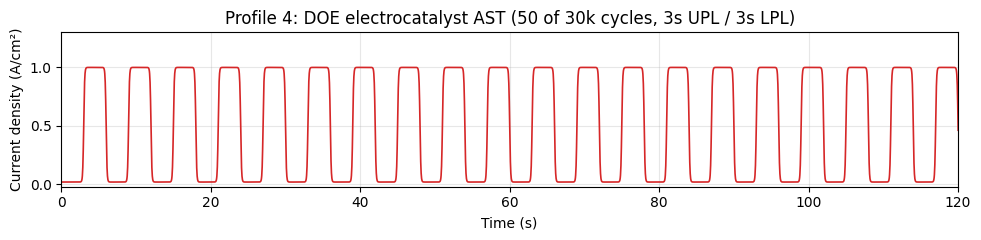

In [6]:
# --- Profile 4: DOE electrocatalyst cycling AST (3s / 3s) ---
# Original protocol: voltage-controlled square wave 0.60 V ↔ 0.95 V
# Approximated here as current-density cycling for the current-driven model.
n_cycles_doe = 50       # Show 50 cycles (out of 30,000 target)
t_upl_doe = 3           # s at UPL (0.95 V → near-idle current)
t_lpl_doe = 3           # s at LPL (0.60 V → high current)
t_period_doe = t_upl_doe + t_lpl_doe  # 6 s per cycle
t_doe_total = n_cycles_doe * t_period_doe

# Current density mapping (approximate from polarization curve):
#   UPL ≈ 0.95 V → very low current (near OCV)  →  i_idle
#   LPL ≈ 0.60 V → high current                  →  i_high
tau_doe = 0.5  # s — fast transition (~0.5 s rise time per DOE spec)

def doe_ast_profile(t):
    """DOE electrocatalyst AST: 3s UPL / 3s LPL square wave."""
    i_fc = i_idle
    for k in range(n_cycles_doe):
        t_on  = k * t_period_doe + t_upl_doe
        t_off = k * t_period_doe + t_upl_doe + t_lpl_doe
        i_fc = i_fc + (i_high - i_idle) * smooth_pulse(t, t_on, t_off, tau=tau_doe)
    return i_fc

t_doe = np.linspace(0, t_doe_total, 10000)
i_doe_arr = np.array([doe_ast_profile(ti) for ti in t_doe])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_doe, i_doe_arr / 1e4, linewidth=1.2, color="tab:red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current density (A/cm²)")
ax.set_title(f"Profile 4: DOE electrocatalyst AST ({n_cycles_doe} of 30k cycles, "
             f"{t_upl_doe}s UPL / {t_lpl_doe}s LPL)")
ax.set_ylim(-0.02, i_high / 1e4 * 1.3)
ax.set_xlim(0, min(t_doe_total, 120))  # Zoom to first 120 s for readability
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Start-stop cycling

Simulates vehicle start-up / shut-down events. Each cycle:
- **Idle** → **Ramp to nominal load** → **Hold** → **Ramp down to idle**

Start-stop events cause H₂/air fronts at the anode, leading to high local cathode potentials (>1.4 V) and severe carbon corrosion.

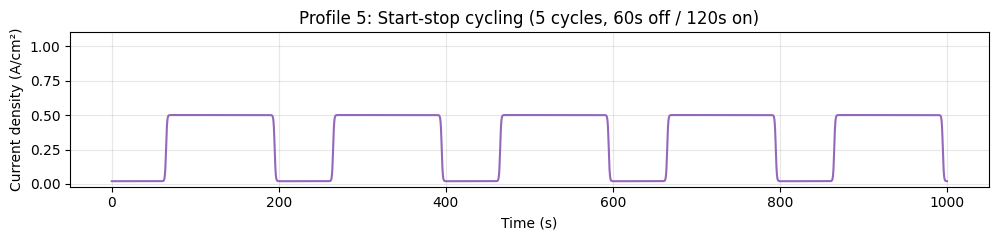

In [7]:
# --- Profile 5: Start-stop cycling ---
n_cycles_ss = 5
t_off_ss   = 60   # s off / idle
t_ramp_ss  = 10   # s ramp up/down
t_on_ss    = 120  # s at nominal load
t_period_ss = t_off_ss + t_ramp_ss + t_on_ss + t_ramp_ss
t_ss_total = n_cycles_ss * t_period_ss

def start_stop_profile(t):
    """Start-stop cycling with ramp transitions."""
    i_fc = i_idle
    for k in range(n_cycles_ss):
        t0 = k * t_period_ss
        t_start = t0 + t_off_ss
        t_full  = t_start + t_ramp_ss
        t_stop  = t_full + t_on_ss
        t_end   = t_stop + t_ramp_ss
        # Ramp up then ramp down
        i_fc = i_fc + (i_mid - i_idle) * (
            smooth_step(t, t_start + t_ramp_ss / 2, tau=t_ramp_ss / 2) -
            smooth_step(t, t_stop + t_ramp_ss / 2, tau=t_ramp_ss / 2)
        )
    return i_fc

t_ss = np.linspace(0, t_ss_total, 5000)
i_ss_arr = np.array([start_stop_profile(ti) for ti in t_ss])

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_ss, i_ss_arr / 1e4, linewidth=1.5, color="tab:purple")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current density (A/cm²)")
ax.set_title(f"Profile 5: Start-stop cycling ({n_cycles_ss} cycles, "
             f"{t_off_ss}s off / {t_on_ss}s on)")
ax.set_ylim(-0.02, i_high / 1e4 * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. NEDC drive cycle

The New European Driving Cycle (1180 s) consists of 4 repeated ECE-15 urban cycles (4 x 195 s) followed by 1 EUDC extra-urban segment (400 s). The vehicle speed profile is converted to a PEMFC current density demand using:

$$i(t) = i_\text{idle} + (i_\text{max} - i_\text{idle}) \cdot \left(\frac{v(t)}{v_\text{max}}\right)^2$$

The quadratic mapping captures the dominant aerodynamic drag dependence ($P \propto v^3$, but $P = i \cdot V$ with $V$ roughly constant at mid-load).

NEDC total duration: 1180 s
Max speed: 120 km/h


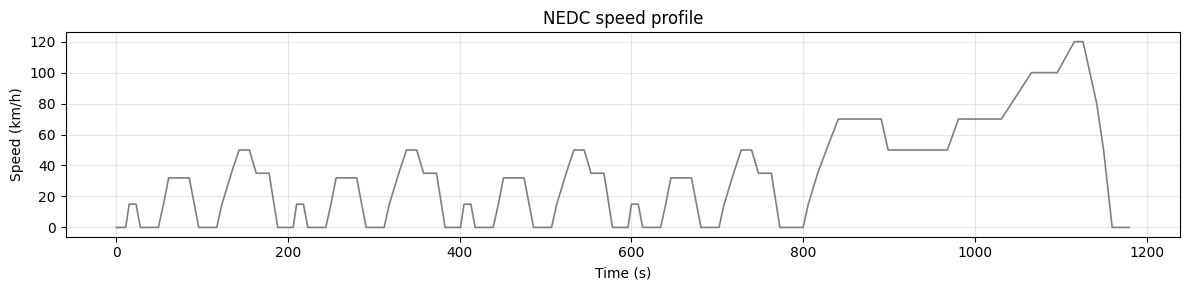

In [8]:
# --- Profile 6: NEDC drive cycle ---
# ECE-15 urban cycle segment table (one cycle = 195 s)
# Each row: (start_v km/h, end_v km/h, duration s)
ece15_segments = [
    (0,   0,  11),   # idle
    (0,  15,   4),   # accelerate
    (15, 15,   8),   # cruise 15
    (15,  0,   5),   # decelerate
    (0,   0,  21),   # idle
    (0,  15,   6),   # accelerate
    (15, 32,   6),   # accelerate
    (32, 32,  24),   # cruise 32
    (32,  0,  11),   # decelerate
    (0,   0,  21),   # idle
    (0,  15,   6),   # accelerate
    (15, 35,  11),   # accelerate
    (35, 50,   9),   # accelerate
    (50, 50,  12),   # cruise 50
    (50, 35,   8),   # decelerate
    (35, 35,  15),   # cruise 35
    (35,  0,  10),   # decelerate
    (0,   0,   7),   # idle
]

# EUDC extra-urban segment table (400 s)
eudc_segments = [
    (0,    0,   20),  # idle
    (0,   15,    6),  # accelerate
    (15,  35,   11),  # accelerate
    (35,  50,   10),  # accelerate
    (50,  70,   14),  # accelerate
    (70,  70,   50),  # cruise 70
    (70,  50,    8),  # decelerate
    (50,  50,   69),  # cruise 50
    (50,  70,   13),  # accelerate
    (70,  70,   50),  # cruise 70
    (70, 100,   35),  # accelerate
    (100,100,   30),  # cruise 100
    (100,120,   20),  # accelerate
    (120,120,   10),  # cruise 120
    (120, 80,   16),  # decelerate
    (80,  50,    8),  # decelerate
    (50,   0,   10),  # decelerate
    (0,    0,   20),  # idle
]

def build_speed_profile(segments, dt=1.0):
    """Build a second-by-second speed array from segment table."""
    t_list, v_list = [], []
    t_cum = 0.0
    for v_start, v_end, duration in segments:
        n_pts = max(int(duration / dt), 1)
        t_seg = np.linspace(t_cum, t_cum + duration, n_pts, endpoint=False)
        v_seg = np.linspace(v_start, v_end, n_pts, endpoint=False)
        t_list.append(t_seg)
        v_list.append(v_seg)
        t_cum += duration
    # Append final point
    t_list.append(np.array([t_cum]))
    v_list.append(np.array([segments[-1][1]]))
    return np.concatenate(t_list), np.concatenate(v_list)

# Build full NEDC: 4 x ECE-15 + 1 x EUDC
t_nedc_parts, v_nedc_parts = [], []
t_offset = 0.0
for _ in range(4):
    t_seg, v_seg = build_speed_profile(ece15_segments)
    t_nedc_parts.append(t_seg + t_offset)
    v_nedc_parts.append(v_seg)
    t_offset += 195.0

t_eudc, v_eudc = build_speed_profile(eudc_segments)
t_nedc_parts.append(t_eudc + t_offset)
v_nedc_parts.append(v_eudc)

t_nedc = np.concatenate(t_nedc_parts)
v_nedc = np.concatenate(v_nedc_parts)  # km/h

# Remove duplicate time points from concatenation
mask = np.diff(t_nedc, prepend=-1) > 0
t_nedc = t_nedc[mask]
v_nedc = v_nedc[mask]

print(f"NEDC total duration: {t_nedc[-1]:.0f} s")
print(f"Max speed: {v_nedc.max():.0f} km/h")

# Plot speed profile
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_nedc, v_nedc, linewidth=1.2, color="tab:gray")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("NEDC speed profile")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

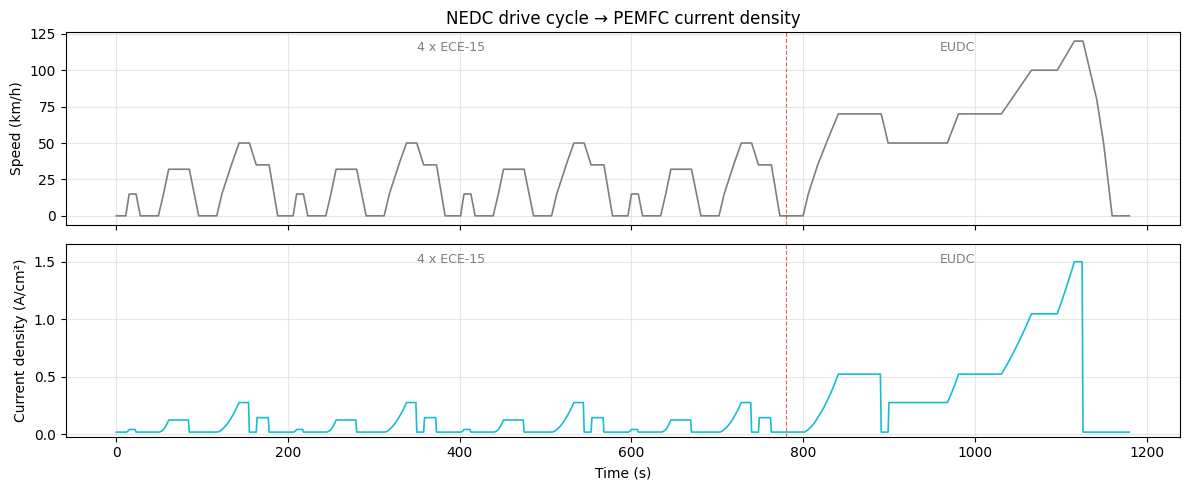

NEDC duration: 1180 s
Current density range: 0.020 – 1.500 A/cm²


In [9]:
# Convert NEDC speed to current density profile
# Quadratic mapping: i(t) = i_idle + (i_max - i_idle) * (v/v_max)^2
# During deceleration, FC drops to idle (regenerative braking charges battery)
v_max_nedc = 120.0  # km/h — NEDC peak speed

# Compute acceleration to detect deceleration phases
dv_dt = np.gradient(v_nedc, t_nedc)

# Current density profile
i_nedc = np.where(
    (v_nedc <= 0.5) | (dv_dt < -0.3),  # idle or decelerating
    i_idle,
    i_idle + (i_max - i_idle) * (v_nedc / v_max_nedc) ** 2
)

# Build an interpolation function for use with solve_ivp
from scipy.interpolate import interp1d
nedc_current_func = interp1d(t_nedc, i_nedc, kind='linear', fill_value=i_idle, bounds_error=False)

def nedc_profile(t):
    """NEDC current density profile (A/m²). Compatible with operating_inputs['current_density']."""
    return float(nedc_current_func(t))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t_nedc, v_nedc, linewidth=1.2, color="tab:gray")
axes[0].set_ylabel("Speed (km/h)")
axes[0].set_title("NEDC drive cycle → PEMFC current density")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_nedc, i_nedc / 1e4, linewidth=1.2, color="tab:cyan")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current density (A/cm²)")
axes[1].set_ylim(-0.02, i_max / 1e4 * 1.1)
axes[1].grid(True, alpha=0.3)

# Annotate ECE-15 / EUDC regions
for ax in axes:
    ax.axvline(x=780, color="tab:red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(390, ax.get_ylim()[1] * 0.9, "4 x ECE-15", ha="center", fontsize=9, color="tab:gray")
    ax.text(980, ax.get_ylim()[1] * 0.9, "EUDC", ha="center", fontsize=9, color="tab:gray")

plt.tight_layout()
plt.show()

print(f"NEDC duration: {t_nedc[-1]:.0f} s")
print(f"Current density range: {i_nedc.min()/1e4:.3f} – {i_nedc.max()/1e4:.3f} A/cm²")

## Summary comparison

All six profiles plotted together for comparison.

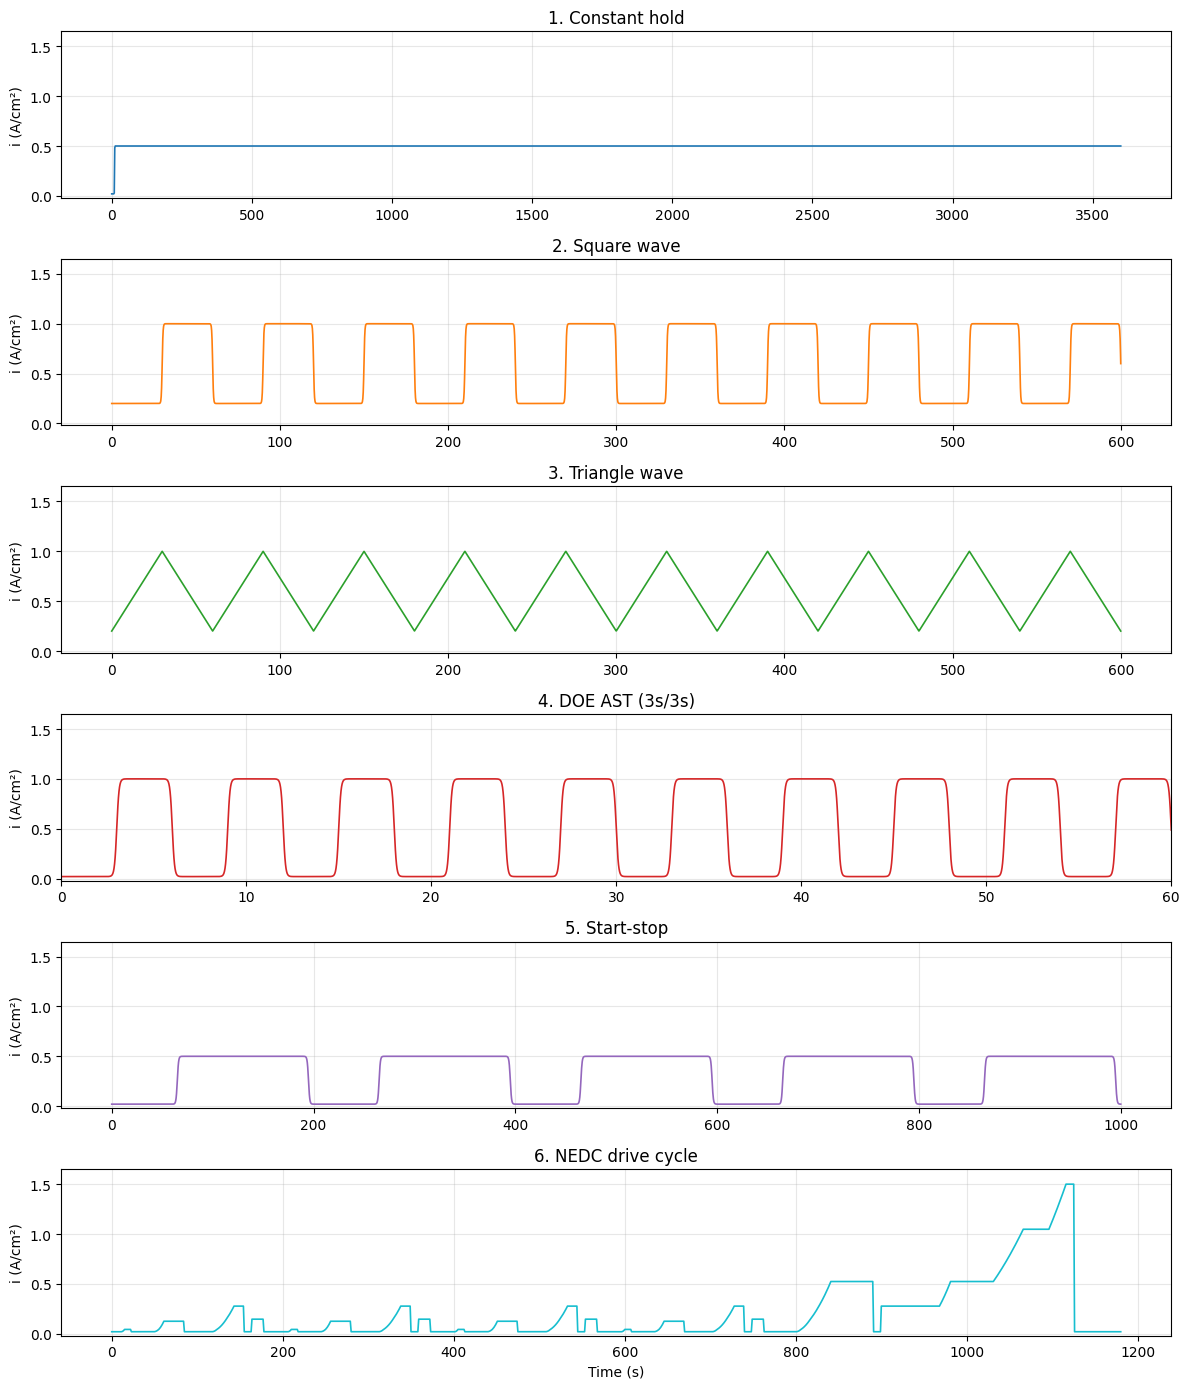

Profile                      Duration (s)   i_min (A/cm²)   i_max (A/cm²)
---------------------------------------------------------------------------
1. Constant hold                     3600           0.020           0.500
2. Square wave                        600           0.200           1.000
3. Triangle wave                      600           0.200           1.000
4. DOE AST (3s/3s)                    300           0.020           1.000
5. Start-stop                        1000           0.020           0.500
6. NEDC drive cycle                  1180           0.020           1.500


In [10]:
# --- Summary: all profiles side by side ---
profiles = [
    ("1. Constant hold",       t_hold, i_hold_arr, "tab:blue"),
    ("2. Square wave",         t_sq,   i_sq_arr,   "tab:orange"),
    ("3. Triangle wave",       t_tri,  i_tri_arr,   "tab:green"),
    ("4. DOE AST (3s/3s)",     t_doe,  i_doe_arr,   "tab:red"),
    ("5. Start-stop",          t_ss,   i_ss_arr,    "tab:purple"),
    ("6. NEDC drive cycle",    t_nedc, i_nedc,      "tab:cyan"),
]

fig, axes = plt.subplots(len(profiles), 1, figsize=(12, 14), sharex=False)

for ax, (label, t_arr, i_arr, color) in zip(axes, profiles):
    ax.plot(t_arr, i_arr / 1e4, linewidth=1.2, color=color)
    ax.set_ylabel("i (A/cm²)")
    ax.set_title(label)
    ax.set_ylim(-0.02, i_max / 1e4 * 1.1)
    ax.grid(True, alpha=0.3)

# Zoom DOE to first 60s for readability
axes[3].set_xlim(0, 60)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Profile':<28s} {'Duration (s)':>12s}  {'i_min (A/cm²)':>14s}  {'i_max (A/cm²)':>14s}")
print("-" * 75)
for label, t_arr, i_arr, _ in profiles:
    print(f"{label:<28s} {t_arr[-1]:>12.0f}  {i_arr.min()/1e4:>14.3f}  {i_arr.max()/1e4:>14.3f}")

## Using a profile with the PEMFC_1D model

Example: pass any of the above profile functions directly into `operating_inputs["current_density"]` for simulation.

```python
operating_inputs["current_density"] = lambda t: square_wave_profile(t) 
model = PEMFC_1D(parameters, operating_inputs, init_value)
sol = solve_ivp(model.dxdt, (0, t_sq_total), model.x, method='BDF', max_step=0.1)
```